In [19]:
import pandas as pd
import numpy as np
import json
import re
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import make_scorer, mean_squared_error

In [20]:
# --- 1. Load the dataset ---
df = pd.read_csv('../../../data/test-final/FINAL_master.csv')

In [21]:
# 2. Parse the skill vector
def parse_skills(s):
    return np.array(json.loads(s.replace("'", '"')))
df['skills_vec'] = df['skills_vector'].apply(parse_skills)

In [22]:
# 3. Rebuild segment_count if needed (ensure no NaN)
df['segment_count'] = pd.to_numeric(df['segment_count'], errors='coerce').fillna(df['segment_count'].mean())


In [23]:
# 4. Build feature matrix: [skills_vec, segment_count]
X_skills = np.vstack(df['skills_vec'].values)
X = np.hstack([X_skills, df[['segment_count']].values])


In [24]:
# 5a. Regression target
y_reg = df['Overall_Score'].values

In [25]:
# 5b. Classification target from rec_ columns (0=Hire,1=Consider,2=Reject)
rec_cols = ['rec_Hire','rec_Consider','rec_Reject']
y_cls = df[rec_cols].values.argmax(axis=1)


In [26]:
# Prepare CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [27]:
# 6a. Regression CV (using MSE→RMSE)
reg = GradientBoostingRegressor(random_state=42)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
mse_scores = cross_val_score(reg, X, y_reg, cv=cv, scoring=mse_scorer)
rmse_scores = np.sqrt(-mse_scores)
print("Structured‑Only Regression CV RMSE:", np.round(rmse_scores, 3))
print("Mean RMSE:", np.round(rmse_scores.mean(), 3))

Structured‑Only Regression CV RMSE: [0.211 0.193 0.219 0.201 0.22 ]
Mean RMSE: 0.209


In [28]:
# 6b. Classification CV Accuracy
clf = RandomForestClassifier(random_state=42)
acc_scores = cross_val_score(clf, X, y_cls, cv=cv, scoring='accuracy')
print("Structured‑Only Classification CV Accuracy:", np.round(acc_scores, 3))
print("Mean Accuracy:", np.round(acc_scores.mean(), 3))

Structured‑Only Classification CV Accuracy: [0.311 0.317 0.3   0.417 0.35 ]
Mean Accuracy: 0.339


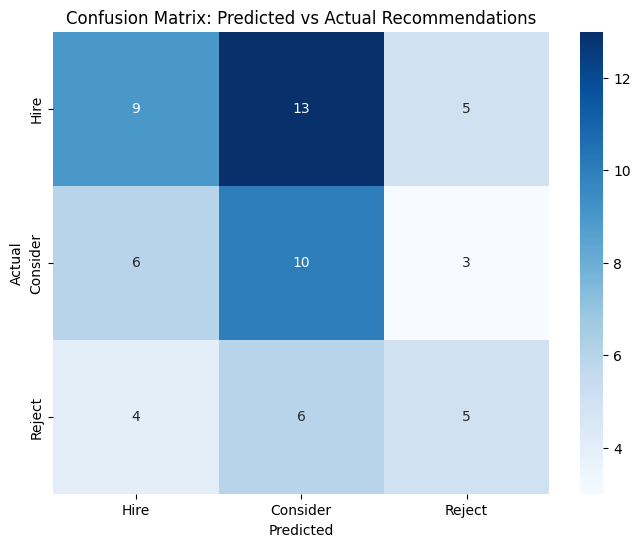

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Define class labels
class_labels = ['Hire', 'Consider', 'Reject']

# Split data for visualization (optional, can use full dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y_cls, test_size=0.2, random_state=42)

# Fit classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix: Predicted vs Actual Recommendations')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

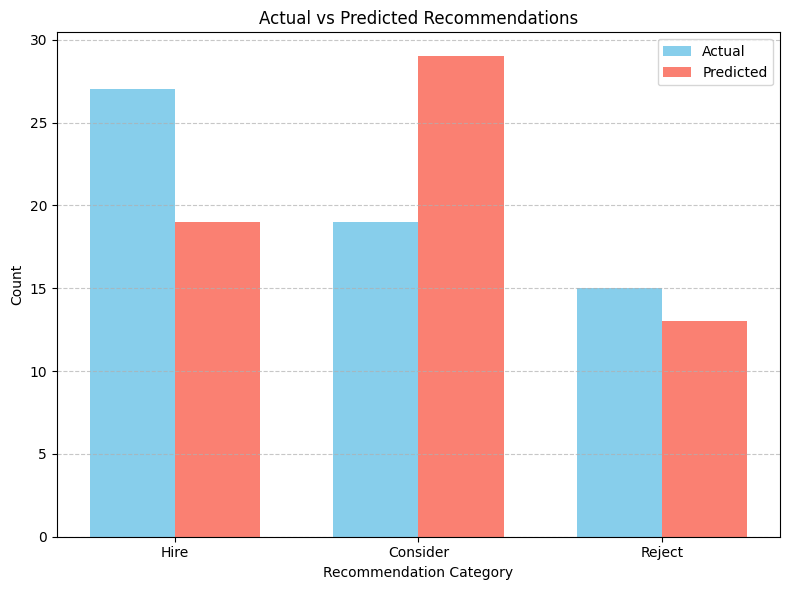

Test Set Accuracy: 0.393


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Define class labels
class_labels = ['Hire', 'Consider', 'Reject']

# Split data for visualization (optional, can use full dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y_cls, test_size=0.2, random_state=42)

# Fit classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Count actual and predicted classes
actual_counts = np.bincount(y_test, minlength=3)  # Ensure length=3 for all classes
predicted_counts = np.bincount(y_pred, minlength=3)

# Set up bar plot
bar_width = 0.35
x = np.arange(len(class_labels))

# Create grouped bar plot
plt.figure(figsize=(8, 6))
plt.bar(x - bar_width/2, actual_counts, bar_width, label='Actual', color='skyblue')
plt.bar(x + bar_width/2, predicted_counts, bar_width, label='Predicted', color='salmon')

# Customize plot
plt.xlabel('Recommendation Category')
plt.ylabel('Count')
plt.title('Actual vs Predicted Recommendations')
plt.xticks(x, class_labels)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print accuracy for context
accuracy = (y_test == y_pred).mean()
print(f"Test Set Accuracy: {accuracy:.3f}")